# SPACESHIP TITANIC

In [181]:
import copy
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression


## Data Import

In [182]:
train_data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")

## Data Preprocess
- Transported/CryoSleep 轉成 0/1
- PassengerId、Name、Cabin 原始欄位不直接當特徵
- PassengerId / Name 會衍生群組特徵
- RoomService / FoodCourt / ShoppingMall / Spa / VRDeck 會衍生消費聚合特徵
- Cabin 缺失值補上 Missing//Missing
    - 把 Cabin 拆成 CabinDeck、CabinNum、CabinSide


In [183]:
def to_binary(series):
    return series.astype(str).map({"False": 0, "True": 1}).astype(float)


def add_basic_features(df):
    df = df.copy()
    passenger_group = (
        df["PassengerId"]
        .astype("string")
        .fillna("Missing")
        .str.split("_", n=1, expand=True)[0]
    )
    passenger_group_size = passenger_group.map(passenger_group.value_counts()).astype(float)
    df["PassengerGroupSize"] = passenger_group_size
    df["PassengerIsAlone"] = (passenger_group_size == 1).astype(float)

    surname = (
        df["Name"]
        .astype("string")
        .fillna("Missing")
        .str.rsplit(" ", n=1)
        .str[-1]
    )
    surname_group_size = surname.map(surname.value_counts()).astype(float)
    df["SurnameGroupSize"] = surname_group_size
    df["SurnameIsAlone"] = (surname_group_size == 1).astype(float)

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    spend_frame = df[spend_cols].fillna(0)
    df["TotalSpend"] = spend_frame.sum(axis=1)
    df["LogTotalSpend"] = np.log1p(df["TotalSpend"])
    df["AnySpend"] = (df["TotalSpend"] > 0).astype(float)
    df["LuxurySpend"] = spend_frame[["Spa", "VRDeck"]].sum(axis=1)
    df["RegularSpend"] = spend_frame[["RoomService", "FoodCourt", "ShoppingMall"]].sum(axis=1)

    df = df.drop(columns=["PassengerId", "Name"], errors="ignore")
    cabin = df["Cabin"].fillna("Missing//Missing").str.split("/", expand=True)
    df["CabinDeck"] = cabin[0]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    df["CabinSide"] = cabin[2]
    return df.drop(columns=["Cabin"])


# Split train / validation first.
X = train_data.drop(columns=["Transported"]).copy()
y = to_binary(train_data["Transported"])
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = add_basic_features(X_train)
X_val = add_basic_features(X_val)


## Baseline 0
先看一個最簡單的 `Transported = CryoSleep` validation accuracy
- 把 validation set 裡 CryoSleep 的缺失值，補成算出的眾數

In [184]:
# 先從 training split 的 CryoSleep 找出最常出現的值
cryo_mode = X_train["CryoSleep"].mode(dropna=True)[0]
# 把 validation split 裡 CryoSleep 的缺失值，補成剛剛算出的眾數
cryo_val = X_val["CryoSleep"].astype("string").fillna(cryo_mode)
cryo_pred = to_binary(cryo_val)
# 直接算 accuracy
acc_b0 = accuracy_score(y_val, cryo_pred >= 0.5)
print(f"Baseline 0 | Transported = CryoSleep | Acc: {acc_b0:.4f}")

Baseline 0 | Transported = CryoSleep | Acc: 0.7131


## Baseline1
Ridge fit training split，再算 validation accuracy

In [190]:
# Baseline 1: Ridge on train split, evaluated on validation split.
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")), # 數值欄位用 median 補缺失值
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")), # 類別欄位用 most_frequent 補缺失值
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=1.0)),
])

model.fit(X_train, y_train)
val_pred = model.predict(X_val)
acc_b1 = accuracy_score(y_val, val_pred >= 0.5)
print(f"Baseline 1 | Ridge val Acc: {acc_b1:.4f}")


Baseline 1 | Ridge val Acc: 0.7723


# XGBoost + Feature Selection + Early Stopping
- 先做缺值補齊 + one-hot
- 用 SelectKBest(f_regression) 選特徵
- 直接用外層 X_val 做 early stopping
- 畫 train / val logloss 曲線看收斂狀況

In [204]:
from xgboost import XGBClassifier



# XGBoost does not need scaling, so we only impute missing values and one-hot encode categoricals.
xgb_numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
xgb_categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

xgb_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), xgb_numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            xgb_categorical_features,
        ),
    ]
)

X_train_pre = xgb_preprocess.fit_transform(X_train)
X_val_pre = xgb_preprocess.transform(X_val)
xgb_feature_names = xgb_preprocess.get_feature_names_out()

# Keep the feature screen compact, then let XGBoost learn on the selected columns.
XGB_SELECT_K = 33
N_ESTIMATORS = 10000
LR=0.01
MAX_DEPTH=5
SUBSAMPLE=0.65
COLSAMPLE_BYTREE=0.9
REG_LAMBDA=0.2
ESR=200


xgb_k = min(XGB_SELECT_K, X_train_pre.shape[1])
selector = SelectKBest(score_func=f_regression, k=xgb_k)
X_train_sel = selector.fit_transform(X_train_pre, y_train)
X_val_sel = selector.transform(X_val_pre)
selected_xgb_feature_names = xgb_feature_names[selector.get_support()]

print(f"XGB_SELECT_K = {xgb_k}")
print(f"preprocessed feature count = {X_train_pre.shape[1]}")
print(f"selected feature count = {len(selected_xgb_feature_names)}")
print("selected features:")
print(list(selected_xgb_feature_names))

xgb_model = XGBClassifier(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    max_depth=MAX_DEPTH,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_lambda=REG_LAMBDA,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=ESR,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_sel,
    y_train.astype(int),
    eval_set=[(X_train_sel, y_train.astype(int)), (X_val_sel, y_val.astype(int))],
    verbose=False,
)
train_acc_xgb = accuracy_score(y_train.astype(int), xgb_model.predict(X_train_sel))
val_acc_xgb = accuracy_score(y_val.astype(int), xgb_model.predict(X_val_sel))
print(f"XGBoost | train acc: {train_acc_xgb:.4f} | val acc: {val_acc_xgb:.4f}")
print(f"best_iteration = {xgb_model.best_iteration}")
print(f"best_score = {xgb_model.best_score}")


XGB_SELECT_K = 33
preprocessed feature count = 38
selected feature count = 33
selected features:
['num__Age', 'num__RoomService', 'num__FoodCourt', 'num__Spa', 'num__VRDeck', 'num__PassengerGroupSize', 'num__PassengerIsAlone', 'num__SurnameIsAlone', 'num__TotalSpend', 'num__LogTotalSpend', 'num__AnySpend', 'num__LuxurySpend', 'num__RegularSpend', 'num__CabinNum', 'cat__HomePlanet_Earth', 'cat__HomePlanet_Europa', 'cat__HomePlanet_Mars', 'cat__CryoSleep_False', 'cat__CryoSleep_True', 'cat__Destination_55 Cancri e', 'cat__Destination_TRAPPIST-1e', 'cat__VIP_False', 'cat__VIP_True', 'cat__CabinDeck_B', 'cat__CabinDeck_C', 'cat__CabinDeck_D', 'cat__CabinDeck_E', 'cat__CabinDeck_F', 'cat__CabinDeck_G', 'cat__CabinDeck_T', 'cat__CabinSide_Missing', 'cat__CabinSide_P', 'cat__CabinSide_S']
XGBoost | train acc: 0.8907 | val acc: 0.8131
best_iteration = 1508
best_score = 0.361783569383308


## Figures

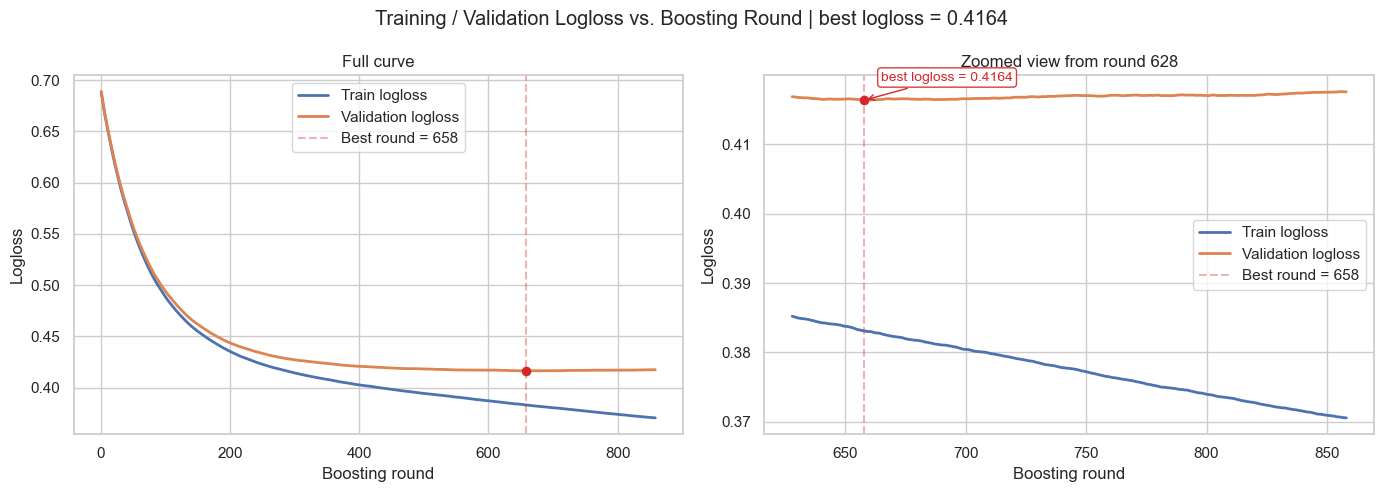

In [189]:

evals_result = xgb_model.evals_result()
train_logloss = evals_result["validation_0"]["logloss"]
val_logloss = evals_result["validation_1"]["logloss"]
rounds = np.arange(1, len(train_logloss) + 1)
best_round = (xgb_model.best_iteration + 1) if xgb_model.best_iteration is not None else int(np.argmin(val_logloss) + 1)
best_idx = best_round - 1
best_val_logloss = val_logloss[best_idx]
zoom_start = max(1, best_round - 30)
zoom_mask = rounds >= zoom_start
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, train_logloss, label='Train logloss', linewidth=2)
axes[0].plot(rounds, val_logloss, label='Validation logloss', linewidth=2)
axes[0].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best round = {best_round}')
axes[0].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Logloss')
axes[0].set_title('Full curve')
axes[0].legend()

axes[1].plot(rounds[zoom_mask], np.array(train_logloss)[zoom_mask], label='Train logloss', linewidth=2)
axes[1].plot(rounds[zoom_mask], np.array(val_logloss)[zoom_mask], label='Validation logloss', linewidth=2)
axes[1].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best round = {best_round}')
axes[1].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[1].annotate(
    f'best logloss = {best_val_logloss:.4f}',
    xy=(best_round, best_val_logloss),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
axes[1].set_xlabel('Boosting round')
axes[1].set_ylabel('Logloss')
axes[1].set_title(f'Zoomed view from round {zoom_start}')
axes[1].legend()

fig.suptitle(f'Training / Validation Logloss vs. Boosting Round | best logloss = {best_val_logloss:.4f}')
fig.tight_layout()
plt.show()

In [113]:
# Final run: retrain on the full training set, write submission.csv, and submit from inside this notebook.
import subprocess
import sys
import shutil
from pathlib import Path

full_train_X = add_basic_features(train_data.drop(columns=["Transported"]).copy())
full_train_y = to_binary(train_data["Transported"])

full_xgb_numeric_features = full_train_X.select_dtypes(include=["number"]).columns.tolist()
full_xgb_categorical_features = full_train_X.select_dtypes(exclude=["number"]).columns.tolist()

full_xgb_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), full_xgb_numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            full_xgb_categorical_features,
        ),
    ]
)

full_X_pre = full_xgb_preprocess.fit_transform(full_train_X)
full_xgb_feature_names = full_xgb_preprocess.get_feature_names_out()

final_k = min(XGB_SELECT_K, full_X_pre.shape[1])
final_selector = SelectKBest(score_func=f_regression, k=final_k)
full_X_sel = final_selector.fit_transform(full_X_pre, full_train_y)
selected_full_feature_names = full_xgb_feature_names[final_selector.get_support()]

final_n_estimators = getattr(xgb_model, "best_iteration", None)
final_n_estimators = N_ESTIMATORS if final_n_estimators is None else int(final_n_estimators) + 1
final_n_estimators = max(1, final_n_estimators)

def fmt_param(value):
    return str(value).replace(".", "p")

submission_path = (
    f"submission_xgb_full_k{final_k}_nt{final_n_estimators}"
    f"_lr{fmt_param(LR)}_md{MAX_DEPTH}_ss{fmt_param(SUBSAMPLE)}"
    f"_cs{fmt_param(COLSAMPLE_BYTREE)}_rl{fmt_param(REG_LAMBDA)}.csv"
)

print(f"final_n_estimators = {final_n_estimators}")
print(f"final selected feature count = {len(selected_full_feature_names)}")
print("final selected features:")
print(list(selected_full_feature_names))

final_xgb_model = XGBClassifier(
    n_estimators=final_n_estimators,
    learning_rate=LR,
    max_depth=MAX_DEPTH,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_lambda=REG_LAMBDA,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

final_xgb_model.fit(full_X_sel, full_train_y.astype(int), verbose=False)

test_raw = add_basic_features(test_data.copy())
X_test_pre = full_xgb_preprocess.transform(test_raw)
X_test_sel = final_selector.transform(X_test_pre)
test_pred = final_xgb_model.predict(X_test_sel).astype(bool)

sample_submission = pd.read_csv("./data/sample_submission.csv")
submission = sample_submission.copy()
submission["Transported"] = test_pred
submission.to_csv(submission_path, index=False)

print(submission.head())
print(f"saved to {submission_path} with shape {submission.shape}")

kaggle_exe = shutil.which("kaggle") or str(Path(sys.executable).with_name("kaggle"))
submit_cmd = [kaggle_exe, "competitions", "submit", "-c", "spaceship-titanic", "-f", submission_path, 
              "-m", "XGBoost early stopping / flat SelectKBest / PassengerId & Name features process / Spend features process"]
print("Running:", " ".join(submit_cmd))
try:
    result = subprocess.run(submit_cmd, check=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
except FileNotFoundError:
    print("kaggle CLI not found in this notebook kernel environment.")
except subprocess.CalledProcessError as exc:
    print("Kaggle submit failed.")
    if exc.stdout:
        print(exc.stdout)
    if exc.stderr:
        print(exc.stderr)
    raise


final_n_estimators = 645
final selected feature count = 16
final selected features:
['num__RoomService', 'num__Spa', 'num__VRDeck', 'num__PassengerIsAlone', 'num__TotalSpend', 'num__LogTotalSpend', 'num__AnySpend', 'num__LuxurySpend', 'cat__HomePlanet_Earth', 'cat__HomePlanet_Europa', 'cat__CryoSleep_False', 'cat__CryoSleep_True', 'cat__Destination_55 Cancri e', 'cat__CabinDeck_B', 'cat__CabinDeck_C', 'cat__CabinSide_S']
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
saved to submission_xgb_full_k16_nt645_lr0p01_md5_ss0p6_cs0p85_rl1p0.csv with shape (4277, 2)
Running: /opt/homebrew/Caskroom/miniconda/base/envs/ml/bin/kaggle competitions submit -c spaceship-titanic -f submission_xgb_full_k16_nt645_lr0p01_md5_ss0p6_cs0p85_rl1p0.csv -m XGBoost early stopping / flat SelectKBest / PassengerId & Name features process / Spend features process
Kaggle submit failed.
400 Client Erro

CalledProcessError: Command '['/opt/homebrew/Caskroom/miniconda/base/envs/ml/bin/kaggle', 'competitions', 'submit', '-c', 'spaceship-titanic', '-f', 'submission_xgb_full_k16_nt645_lr0p01_md5_ss0p6_cs0p85_rl1p0.csv', '-m', 'XGBoost early stopping / flat SelectKBest / PassengerId & Name features process / Spend features process']' returned non-zero exit status 1.